### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# display entire and all columns in results
pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns', None)


### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [73]:
data = pd.read_csv('../data/raw/coupons.csv')

In [74]:
df = data

# change dtype for age to int where 20 reprecents less than 21 and 50 reprecents 50+
age_map = {
    'below21': '20',
    '50plus': '50'
}
df['age'] = df['age'].replace(age_map).astype('int')

df.describe()

,temperature,age,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,32.296515,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,10.187216,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,20.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,21.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,31.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,41.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,50.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


2. Investigate the dataset for missing or problematic data.

In [75]:
df.isnull().sum()
df.isnull().mean() *100


destination              0.000000
passanger                0.000000
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.000000
gender                   0.000000
age                      0.000000
maritalStatus            0.000000
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.190476
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

In [76]:
df['car'].unique()
df[df['Bar'].isna()]

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
517,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,50,Divorced,1,Some college - no degree,Management,$62500 - $74999,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0
518,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,50,Divorced,1,Some college - no degree,Management,$62500 - $74999,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0
519,No Urgent Place,Friend(s),Sunny,80,2PM,Restaurant(<20),1d,Male,50,Divorced,1,Some college - no degree,Management,$62500 - $74999,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,1,1
520,No Urgent Place,Friend(s),Sunny,80,6PM,Coffee House,2h,Male,50,Divorced,1,Some college - no degree,Management,$62500 - $74999,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0
521,No Urgent Place,Friend(s),Sunny,55,2PM,Coffee House,2h,Male,50,Divorced,1,Some college - no degree,Management,$62500 - $74999,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12168,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Female,31,Single,0,Associates degree,Arts Design Entertainment Sports & Media,$75000 - $87499,NaN,NaN,less1,gt8,1~3,less1,1,0,0,1,0,0
12169,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Female,31,Single,0,Associates degree,Arts Design Entertainment Sports & Media,$75000 - $87499,NaN,NaN,less1,gt8,1~3,less1,1,0,0,0,1,0
12170,Work,Alone,Snowy,30,7AM,Coffee House,1d,Female,31,Single,0,Associates degree,Arts Design Entertainment Sports & Media,$75000 - $87499,NaN,NaN,less1,gt8,1~3,less1,1,0,0,1,0,1
12171,Work,Alone,Snowy,30,7AM,Bar,1d,Female,31,Single,0,Associates degree,Arts Design Entertainment Sports & Media,$75000 - $87499,NaN,NaN,less1,gt8,1~3,less1,1,1,1,0,1,0


3. Decide what to do about your missing data -- drop, replace, other...

In [77]:
# drop car column as it is over 99% empty and values appear to be entered freee style such as 'Car that is too old to install Onstar :D'
# keeping NaN in five restaurant categories as these are none answers for one but generaly another has an answer
df2 = df.drop(columns=['car'])
df2


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,NaN,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,0,Bachelors degree,Sales & Related,$75000 - $87499,never,never,1~3,4~8,1~3,1,1,1,0,1,0


4. What proportion of the total observations chose to accept the coupon?



In [78]:
df2['Y'].value_counts(normalize=True) * 100

Y
1    56.843267
0    43.156733
Name: proportion, dtype: float64

5. Use a bar plot to visualize the `coupon` column.

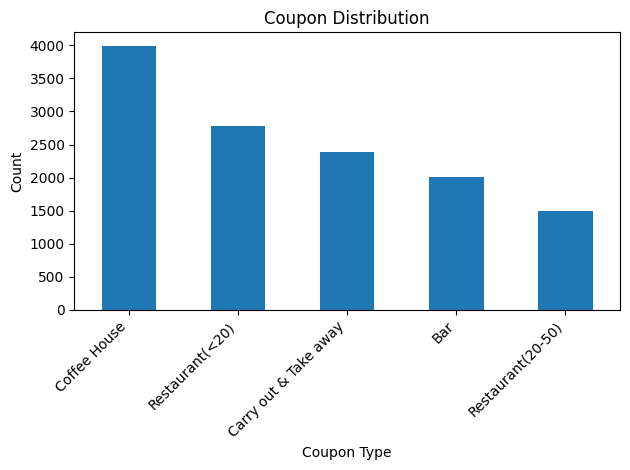

In [79]:
df2['coupon'].value_counts().plot(kind='bar')
plt.title('Coupon Distribution')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

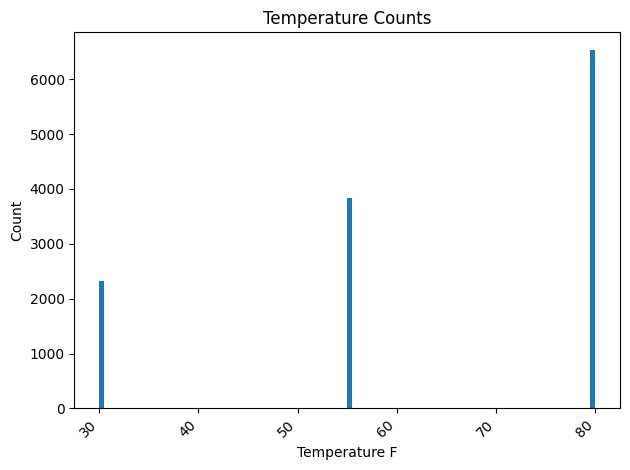

In [80]:
# df2['temperature'].value_counts().sort_index()
df2['temperature'].plot(kind='hist',bins=100)
plt.title('Temperature Counts')
plt.xlabel('Temperature F')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [81]:
dfbc = df2[df2['coupon']=='Bar']

2. What proportion of bar coupons were accepted?


In [82]:
# dfbc3 = dfbc['']
dfbc['Y'].value_counts(normalize=True) * 100

Y
0    58.998513
1    41.001487
Name: proportion, dtype: float64

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [83]:
# drop Nan in Bar
dfbc_frq = dfbc.dropna(subset='Bar')

# Remap values
freq_map = {
    'never': '3 or fewer',
    'less1': '3 or fewer',
    '1~3': '3 or fewer',
    '4~8': '4 or more',
    'gt8': '4 or more'
}
dfbc_frq['Bar'] = dfbc_frq['Bar'].map(freq_map)

# Get acceptance Y = 1 for <=3 and >3
dfbc_frq.groupby('Bar')['Y'].mean().mul(100).round(1).rename('% Accepted Bar Coupon')


Bar
3 or fewer    37.1
4 or more     76.9
Name: % Accepted Bar Coupon, dtype: float64

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [84]:
# drop Nan in Bar
dfbc_frq2 = dfbc.dropna(subset='Bar')

# group values for Bar frequency to desired ranges
freq_map2 = {
    'never': 'less than once per moth',
    'less1': 'less than once per moth',
    '1~3': 'more than once per moth',
    '4~8': 'more than once per moth',
    'gt8': 'more than once per moth'
}
dfbc_frq2['Bar'] = dfbc_frq2['Bar'].map(freq_map2)

# Create new column FreqBarAndOver25
dfbc_frq2['FreqBarAndOver25'] = (
    (dfbc_frq2['Bar'].isin(['more than once per moth'])) &
    (dfbc_frq2['age'] >= 25)
).astype(int)

# Get acceptance Y = 1 for <=3 and >3
dfbc_frq2.groupby('FreqBarAndOver25')['Y'].mean().mul(100).round(1).rename('% Accepted Bar Coupon Frequents Bar More than Once per Month and Over 25')

FreqBarAndOver25
0    33.4
1    69.5
Name: % Accepted Bar Coupon Frequents Bar More than Once per Month and Over 25, dtype: float64

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [85]:
# drop Nan in Bar
dfbc_frq3 = None
dfbc_frq3 = dfbc.dropna(subset='Bar')

# group values for Bar frequency to desired ranges
freq_map3 = {
    'never': 'less than once per moth',
    'less1': 'less than once per moth',
    '1~3': 'more than once per moth',
    '4~8': 'more than once per moth',
    'gt8': 'more than once per moth'
}
dfbc_frq3['Bar'] = dfbc_frq3['Bar'].map(freq_map3)

# Create new column FreqBarAndOver25
dfbc_frq3['FreqBarNoKidsNoAg'] = (
    (dfbc_frq3['Bar'].isin(['more than once per moth'])) &
    ~(dfbc_frq3['passanger'].isin(['Kid(s)','Alone'])) &
    ~(dfbc_frq3['occupation'].isin(['farming','fishing','forestry']))
).astype(int)

#dfbc_frq3[dfbc_frq3['FreqBarNoKidsNoAg']==1]

# Get acceptance Y = 1 for <=3 and >3
dfbc_frq3.groupby('FreqBarNoKidsNoAg')['Y'].mean().mul(100).round(1).rename('% Accepted Bar Coupon Frequents Bar More than Once per Month, Passengers without Kids and Not in farming, fishing or ')

FreqBarNoKidsNoAg
0    37.7
1    71.8
Name: % Accepted Bar Coupon Frequents Bar More than Once per Month, Passengers without Kids and Not in farming, fishing or , dtype: float64

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [86]:
# drop Nan in RestaurantLessThan20
dfbc_frq4 = None
dfbc_frq4 = dfbc.dropna(subset='RestaurantLessThan20')

# group values for RestaurantLessThan20 frequency to desired ranges
freq_map4 = {
    '4~8': 'more than four per month',
    'gt8': 'more than four per month'
}
dfbc_frq4['RestaurantLessThan20'] = dfbc_frq4['RestaurantLessThan20'].map(freq_map4)

# Create income less than 50k column
def extract_lower_bound(val):
    val = val.replace(',', '').replace('$', '')
    if val.startswith('Less than'):
        return 0
    return int(val.split()[0])

dfbc_frq4['IncLess50k'] = (dfbc_frq4['income'].apply(extract_lower_bound) < 50000).astype(int)
dfbc_frq4

# Create new column ResLess20_4More_IncLess50k
dfbc_frq4['ResLess20_4More_IncLess50k'] = (
    (dfbc_frq4['RestaurantLessThan20'] == 'more than four per month') & 
    (dfbc_frq4['IncLess50k'] == 1)
).astype(int)


# dfbc_frq4[dfbc_frq4['ResLess20_4More_IncLess50k']==1]

# Get acceptance Y = 1 for <=3 and >3
dfbc_frq4.groupby('ResLess20_4More_IncLess50k')['Y'].mean().mul(100).round(1).rename('% Accepted Bar Coupon Frequent RestaurantLessThan20 More than 3 per Month and Income Less than 50k')



ResLess20_4More_IncLess50k
0    39.9
1    45.3
Name: % Accepted Bar Coupon Frequent RestaurantLessThan20 More than 3 per Month and Income Less than 50k, dtype: float64

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [87]:

# Accept % ## Filters
########################################################
# 41%.     ## Overall acceptance rate for Bar coupons
# 77%.     ## Acceptance rate for drivers that visit bars four times or more per month
# 69%.     ## Acceptance rate for drivers that visit bars more than once per month and are over 25
# 72%.     ## Acceptance rate for drivers that visit bars more than once per month, have passengers that are not kids and are not in farming, fishing or forestry.


# I can hypothesize that drivers who aleady visit bars are more likely to accept bar coupons.  
# So perhaps the bar coupons are not driving new customers as much as increasin the frequency of those who already visit bars.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

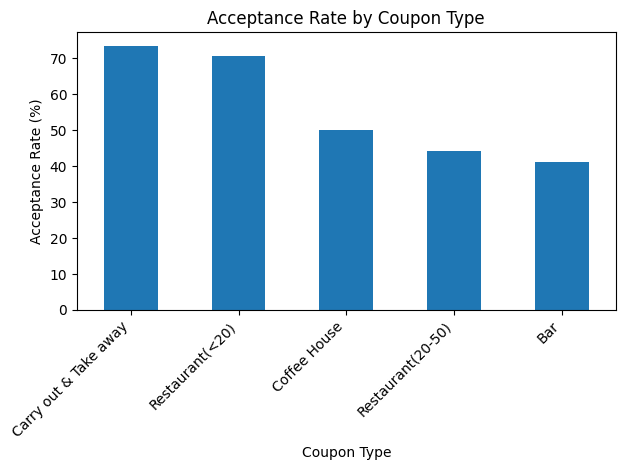

In [ ]:
# Will analize "Carry out & Take away" without having looked at data I hypothesize that time and convinince are factor in acceptance rate
# Compare acceptance rate for Carry out & Take away vs other coupon types
df2.groupby('coupon')['Y'].mean().mul(100).round(1).rename('% Accepted').sort_values(ascending=False).plot(kind='bar')
plt.title('Acceptance Rate by Coupon Type')
plt.xlabel('Coupon Type')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [89]:
# Prep df for analysis of carry out and take away coupons

# Isolate data for carry out and take away coupons
dfta = df2[df2['coupon']=='Carry out & Take away']

# Convert time column to datetime time
dfta['time'] = pd.to_datetime(dfta['time'], format='%I%p').dt.time

# Convert expiration to hours
def expiration_to_hours(val):
    if val.endswith('d'):
        return int(val[:-1]) * 24
    return int(val[:-1])

dfta['expiration'] = dfta['expiration'].apply(expiration_to_hours).astype(int)

# conert income to lower bound of income range.  Zero represents less than 10k and 50 represents 50k or more.
def extract_lower_bound(val):
    val = val.replace(',', '').replace('$', '')
    if val.startswith('Less than'):
        return 0
    return int(val.split()[0])

dfta['income'] = dfta['income'].apply(extract_lower_bound).astype(int)

# add column combining gender and marital status
dfta['gender_marital'] = dfta['gender'] + '_' + dfta['maritalStatus']

dfta

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y,gender_marital
2,No Urgent Place,Friend(s),Sunny,80,10:00:00,Carry out & Take away,2,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,37500,never,never,NaN,4~8,1~3,1,1,0,0,1,1,Female_Unmarried partner
6,No Urgent Place,Friend(s),Sunny,55,14:00:00,Carry out & Take away,24,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,37500,never,never,NaN,4~8,1~3,1,1,0,0,1,1,Female_Unmarried partner
8,No Urgent Place,Kid(s),Sunny,80,10:00:00,Carry out & Take away,2,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,37500,never,never,NaN,4~8,1~3,1,1,0,0,1,1,Female_Unmarried partner
19,Work,Alone,Sunny,80,07:00:00,Carry out & Take away,2,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,37500,never,never,NaN,4~8,1~3,1,0,0,1,0,1,Female_Unmarried partner
25,No Urgent Place,Friend(s),Sunny,80,10:00:00,Carry out & Take away,2,Male,21,Single,0,Bachelors degree,Architecture & Engineering,62500,never,less1,4~8,4~8,less1,1,1,0,0,1,0,Male_Single
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12665,No Urgent Place,Friend(s),Sunny,30,10:00:00,Carry out & Take away,2,Male,26,Single,0,Bachelors degree,Sales & Related,75000,never,never,1~3,4~8,1~3,1,0,0,0,1,1,Male_Single
12672,Home,Alone,Sunny,80,18:00:00,Carry out & Take away,2,Male,26,Single,0,Bachelors degree,Sales & Related,75000,never,never,1~3,4~8,1~3,1,1,0,1,0,0,Male_Single
12673,Home,Alone,Sunny,30,18:00:00,Carry out & Take away,24,Male,26,Single,0,Bachelors degree,Sales & Related,75000,never,never,1~3,4~8,1~3,1,0,0,0,1,0,Male_Single
12679,Home,Partner,Rainy,55,18:00:00,Carry out & Take away,24,Male,26,Single,0,Bachelors degree,Sales & Related,75000,never,never,1~3,4~8,1~3,1,0,0,1,0,1,Male_Single


In [ ]:
# Acceptance rate for carry out and take away coupons is higher than all other coupon types.  Is convinience and children a factor?

# Analyze acceptance rate by feature for carry out and take away coupons
feature_cols = [
    'destination', 'passanger', 'weather', 'temperature', 'time',
    'gender',  'maritalStatus', 'gender_marital','age','has_children', 'education',
    'occupation', 'income', 'CarryAway', 'toCoupon_GEQ5min',
    'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same', 'direction_opp'
]
for col in feature_cols:
    result = dfta.groupby(col)['Y'].mean().mul(100).round(1).rename('% Accepted')
    print(f"\n--- {col} ---")
    print(result.sort_values(ascending=False).to_string())


--- destination ---
destination
Home               78.9
No Urgent Place    76.3
Work               65.5

--- passanger ---
passanger
Friend(s)    75.8
Partner      73.2
Alone        72.7
Kid(s)       70.4

--- weather ---
weather
Sunny    76.3
Snowy    70.7
Rainy    61.1

--- temperature ---
temperature
30    75.6
80    73.0
55    71.9

--- time ---
time
14:00:00    86.7
18:00:00    82.5
22:00:00    75.9
10:00:00    70.2
07:00:00    65.5

--- gender ---
gender
Male      75.9
Female    71.4

--- maritalStatus ---
maritalStatus
Widowed              84.6
Single               74.7
Married partner      73.2
Divorced             72.2
Unmarried partner    71.4

--- gender_marital ---
gender_marital
Male_Divorced               96.0
Female_Widowed              89.5
Male_Single                 76.5
Male_Married partner        75.1
Male_Unmarried partner      73.2
Female_Single               72.1
Female_Married partner      71.7
Male_Widowed                71.4
Female_Unmarried partner    70.1
F

In [91]:
# Analyze acceptance rate by feature for carry out and take away coupons (same as above) for graphing
dfcaf = pd.concat(
    [dfta.groupby(col)['Y'].mean().mul(100).round(1).rename(col) for col in feature_cols],
    axis=1
)

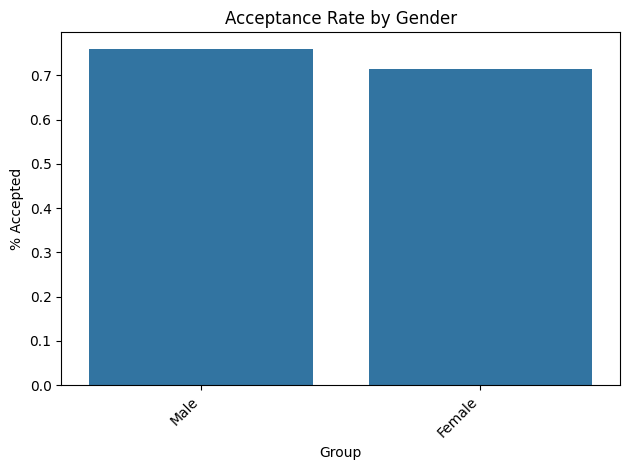

In [ ]:
# Based on acceptance rates above they don't fully support my initial hypothesis that convinice and children are important factors in acceptance rate.
    # convinience
        # direction_opp had a higher acceptance rate than direction_same by 4.7% 
        # time does support original hypothesis noon and 6pm which are traditional meal times
    # children
        # has_children - have and have not are only .8% apart in acceptance rate
        # passanger - when kids were the passanger this was actually the lowest acceptance rate of the group

# Marital Status caught my attention.  Widowed is 10% points higher than any other group. Looking at Gender first:

# Seaborn bar chart of acceptance rate by gender_marital
order = dfta.groupby('gender')['Y'].mean().sort_values(ascending=False).index

sns.barplot(data=dfta, x='gender', y='Y', order=order, estimator='mean', errorbar=None)
plt.title('Acceptance Rate by Gender')
plt.xlabel('Group')
plt.ylabel('% Accepted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

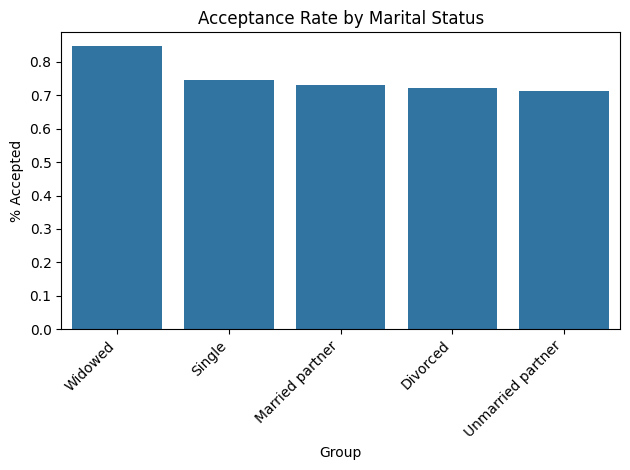

In [ ]:
# Seaborn bar chart of acceptance rate by marital status
order = dfta.groupby('maritalStatus')['Y'].mean().sort_values(ascending=False).index

sns.barplot(data=dfta, x='maritalStatus', y='Y', order=order, estimator='mean', errorbar=None)
plt.title('Acceptance Rate by Marital Status')
plt.xlabel('Group')
plt.ylabel('% Accepted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

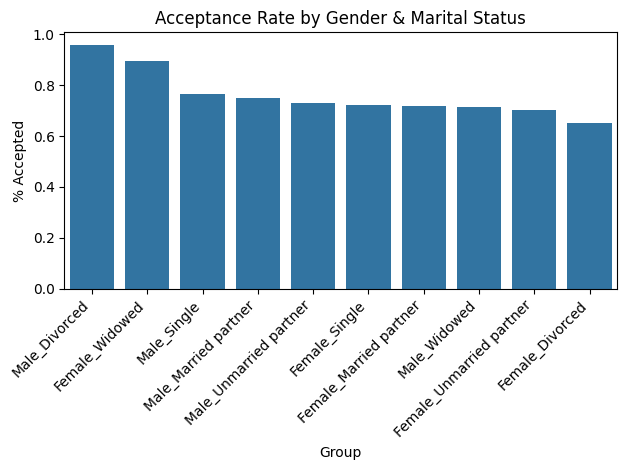

In [ ]:
# Widowed in Merital Status caught my attention so I combined with gender
# Individually they appear even with excpetion of Widowed
# But when you look at them together you can see that there is a large difference between Divoreced Males vs Females and with Widowed Males vs Females.

# Seaborn bar chart of acceptance rate by gender_marital
order = dfta.groupby('gender_marital')['Y'].mean().sort_values(ascending=False).index

sns.barplot(data=dfta, x='gender_marital', y='Y', order=order, estimator='mean', errorbar=None)
plt.title('Acceptance Rate by Gender & Marital Status')
plt.xlabel('Group')
plt.ylabel('% Accepted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


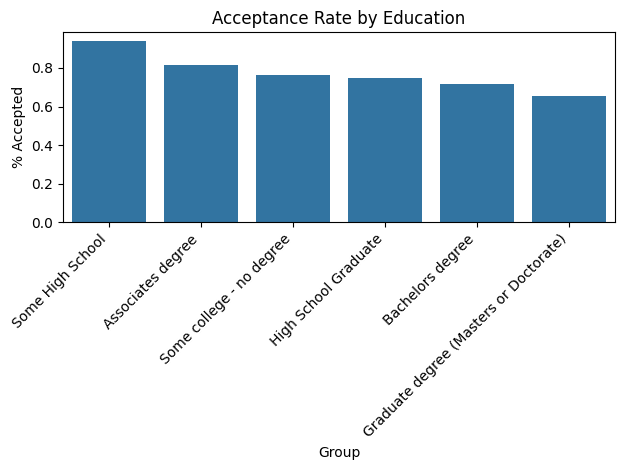

In [ ]:
# Educaiton also made a big differnce with acceptance rate.  Using seaborn showing acceptance rate by education level
# It appears that coupons are less effective with those with higher education levels.

# # Seaborn bar chart of acceptance rate by gender_marital
order = dfta.groupby('education')['Y'].mean().sort_values(ascending=False).index

sns.barplot(data=dfta, x='education', y='Y', order=order, estimator='mean', errorbar=None)
plt.title('Acceptance Rate by Education')
plt.xlabel('Group')
plt.ylabel('% Accepted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()